# Predictive Paradox — Electricity Demand Forecasting Pipeline
IITG.ai Recruitment Task

In [2]:
# ─── 0. IMPORTS ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# Classical ML — the only allowed algorithms
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor  # uncomment if lightgbm is installed
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 120)
print('All imports successful.')

All imports successful.


---
## SECTION 1 — DATA LOADING

In [3]:
PGCB_PATH    = 'PGCB_date_power_demand.xlsx'
WEATHER_PATH = 'weather_data.xlsx'
ECON_PATH    = 'economic_full_1.csv'

pgcb_raw    = pd.read_excel(PGCB_PATH)
weather_raw = pd.read_excel(WEATHER_PATH, skiprows=3)  # rows 0-2 are metadata
econ_raw    = pd.read_csv(ECON_PATH)

print(f'PGCB    shape : {pgcb_raw.shape}')
print(f'Weather shape : {weather_raw.shape}')
print(f'Economic shape: {econ_raw.shape}')

PGCB    shape : (92650, 15)
Weather shape : (107304, 10)
Economic shape: (1516, 69)


---
## SECTION 2 — DATA PREPARATION



In [4]:
def prepare_pgcb(df: pd.DataFrame) -> pd.DataFrame:
   
    df = df.copy()

    # Step 1 — Parse & sort
    df['datetime'] = pd.to_datetime(df['datetime'])
    df = df.sort_values('datetime').reset_index(drop=True)

    # Step 2 — Drop metadata / high-null columns
    cols_to_drop = ['remarks']
    high_null = [c for c in df.columns
                 if df[c].isnull().mean() > 0.80 and c != 'demand_mw']
    df = df.drop(columns=cols_to_drop + high_null, errors='ignore')
    print(f'  Columns kept  : {list(df.columns)}')

    # Step 3 — Round to hour; keep row with highest demand per hour
    df['datetime'] = df['datetime'].dt.round('h')
    df = (
        df.sort_values(['datetime', 'demand_mw'], ascending=[True, False])
          .drop_duplicates(subset='datetime', keep='first')
          .reset_index(drop=True)
    )
    print(f'  Rows after dedup    : {len(df)}')

    # Step 4 — Strict hourly reindex
    full_idx = pd.date_range(df['datetime'].min(),
                              df['datetime'].max(), freq='h')
    df = df.set_index('datetime').reindex(full_idx)
    df.index.name = 'datetime'
    print(f'  Rows after reindex  : {len(df)}')
    print(f'  New NaN in demand_mw: {df["demand_mw"].isnull().sum()}')

    # Step 5 — Interpolate numeric columns only (avoids dtype errors on str columns)
    num_cols = df.select_dtypes(include='number').columns
    df[num_cols] = df[num_cols].interpolate(method='time', limit=6)
    df = df.reset_index()
    print(f'  Remaining NaN demand: {df["demand_mw"].isnull().sum()}')
    return df


pgcb = prepare_pgcb(pgcb_raw)
pgcb[['datetime', 'demand_mw', 'generation_mw']].head(3)

  Columns kept  : ['datetime', 'generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc', 'india_tripura']
  Rows after dedup    : 88046
  Rows after reindex  : 89101
  New NaN in demand_mw: 1055
  Remaining NaN demand: 646


,datetime,demand_mw,generation_mw
0,2015-04-19 00:00:00,4821.0,4821.0
1,2015-04-19 01:00:00,3612.0,3612.0
2,2015-04-19 02:00:00,3727.0,3727.0


### 2B — PGCB: Anomaly Detection & Smoothing

  "demand_mw" outliers: 53 (0.06%)
  "generation_mw" outliers: 20 (0.02%)


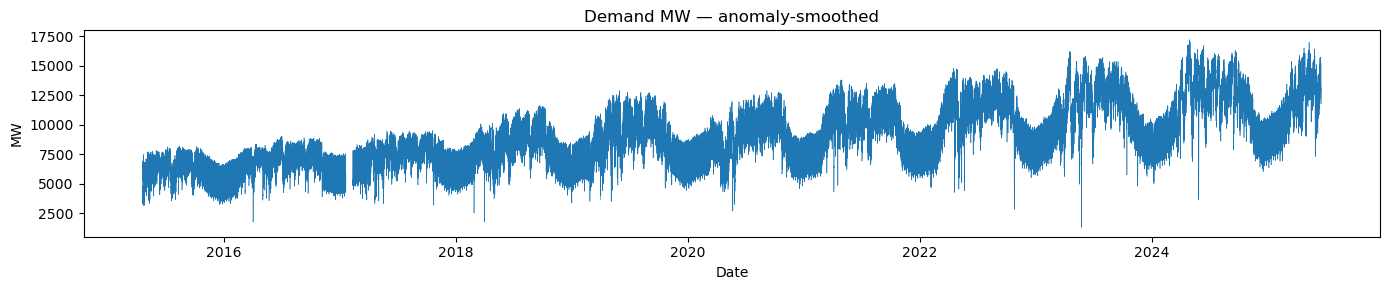

In [5]:
def detect_and_smooth_anomalies(df: pd.DataFrame,
                                 col: str = 'demand_mw',
                                 window: int = 168,
                                 iqr_multiplier: float = 3.0) -> pd.DataFrame:
    """
    Detect and smooth extreme outliers using a rolling IQR fence.
    Flagged values are replaced with a centred 24h rolling median.
    """
    df = df.copy()
    series = df[col].astype(float)

    roll = series.rolling(window=window, center=True, min_periods=window // 4)
    q1, q3 = roll.quantile(0.25), roll.quantile(0.75)
    iqr = q3 - q1
    mask = (series < q1 - iqr_multiplier * iqr) | (series > q3 + iqr_multiplier * iqr)
    print(f'  "{col}" outliers: {mask.sum()} ({100*mask.sum()/len(series):.2f}%)')

    rolling_median = series.rolling(window=24, center=True, min_periods=6).median()
    df[col] = np.where(mask, rolling_median, series)
    df[f'{col}_was_outlier'] = mask.astype(int)
    return df


pgcb = detect_and_smooth_anomalies(pgcb, 'demand_mw')
pgcb = detect_and_smooth_anomalies(pgcb, 'generation_mw')

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(pgcb['datetime'], pgcb['demand_mw'], lw=0.4, label='demand_mw (cleaned)')
ax.set(title='Demand MW — anomaly-smoothed', xlabel='Date', ylabel='MW')
plt.tight_layout(); plt.show()

### 2C — Weather: Clean & Rename

In [6]:
def prepare_weather(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').reset_index(drop=True)
    rename_map = {
        'time'                           : 'datetime',
        'temperature_2m (°C)'            : 'temperature_c',
        'relative_humidity_2m (%)'       : 'humidity_pct',
        'apparent_temperature (°C)'      : 'apparent_temp_c',
        'precipitation (mm)'             : 'precipitation_mm',
        'dew_point_2m (°C)'              : 'dew_point_c',
        'soil_temperature_0_to_7cm (°C)' : 'soil_temp_c',
        'wind_direction_10m (°)'         : 'wind_dir_deg',
        'cloud_cover (%)'                : 'cloud_cover_pct',
        'sunshine_duration (s)'          : 'sunshine_s',
    }
    df = df.rename(columns=rename_map)
    df[df.select_dtypes(include='number').columns] = \
        df.select_dtypes(include='number').interpolate(method='linear', limit=6)
    print(f'  Weather rows: {len(df)}  |  Nulls: {df.isnull().sum().sum()}')
    return df


weather = prepare_weather(weather_raw)
weather.head(3)

  Weather rows: 107304  |  Nulls: 0


,datetime,temperature_c,humidity_pct,apparent_temp_c,precipitation_mm,dew_point_c,soil_temp_c,wind_dir_deg,cloud_cover_pct,sunshine_s
0,2014-01-01 00:00:00,13.9,89,13.3,0.0,12.1,16.4,313,0,0.0
1,2014-01-01 01:00:00,13.6,91,13.2,0.0,12.1,16.0,317,0,0.0
2,2014-01-01 02:00:00,13.3,91,12.8,0.0,11.9,15.7,317,0,0.0


### 2D — Economic Data: Select, Pivot, Lag, and Forward-Fill

In [7]:
SELECTED_INDICATORS = {
    'NY.GDP.MKTP.CD'     : 'gdp_current_usd',
    'NY.GDP.MKTP.KD.ZG'  : 'gdp_growth_pct',
    'NY.GDP.PCAP.CD'     : 'gdp_per_capita_usd',
    'SP.POP.TOTL'        : 'population_total',
    'SP.URB.TOTL'        : 'urban_population',
    'EG.USE.ELEC.KH.PC'  : 'elec_use_kwh_per_capita',
    'EG.ELC.ACCS.ZS'     : 'elec_access_pct',
    'NV.IND.MANF.ZS'     : 'manufacturing_gdp_pct',
    'EN.POP.DNST'        : 'pop_density',
    'EG.USE.COMM.FO.ZS'  : 'fossil_fuel_pct',
}


def prepare_economic(df: pd.DataFrame,
                     selected: dict,
                     year_lag: int = 1) -> pd.DataFrame:
    """
    Pivot wide-format World Bank CSV to one row per (merge_year).
    year_lag=1 applies a 1-year publication delay to prevent look-ahead.
    """
    df = df.copy()
    df = df[df['Indicator Code'].isin(selected.keys())].copy()
    df['Indicator Code'] = df['Indicator Code'].map(selected)
    df = df.drop(columns=['Country Name', 'Indicator Name'], errors='ignore')

    year_cols = [c for c in df.columns if c.isdigit() and 1960 <= int(c) <= 2030]
    df_long = df.melt(id_vars='Indicator Code',
                      value_vars=year_cols,
                      var_name='data_year',
                      value_name='value')
    df_long['data_year'] = df_long['data_year'].astype(int)
    df_long = df_long.rename(columns={'Indicator Code': 'indicator'})

    df_wide = df_long.pivot_table(index='data_year',
                                   columns='indicator',
                                   values='value')
    df_wide.columns.name = None
    df_wide = df_wide.reset_index()
    df_wide['merge_year'] = df_wide['data_year'] + year_lag
    df_wide = df_wide.drop(columns='data_year')
    df_wide = df_wide.sort_values('merge_year').reset_index(drop=True)

    econ_feature_cols = [c for c in df_wide.columns if c != 'merge_year']
    df_wide[econ_feature_cols] = df_wide[econ_feature_cols].ffill().bfill()

    print(f'  Economic table: {df_wide.shape}')
    print(f'  Merge years   : {df_wide["merge_year"].min()} – {df_wide["merge_year"].max()}')
    return df_wide


econ = prepare_economic(econ_raw, SELECTED_INDICATORS, year_lag=1)
econ.head(3)

  Economic table: (65, 11)
  Merge years   : 1961 – 2025


,elec_access_pct,elec_use_kwh_per_capita,fossil_fuel_pct,gdp_current_usd,gdp_growth_pct,gdp_per_capita_usd,manufacturing_gdp_pct,pop_density,population_total,urban_population,merge_year
0,14.29,46.007605,45.470214,4.274894e+09,6.058161,82.481277,5.309911,409.544042,51828660.0,2649573.0,1961
1,14.29,46.007605,45.470214,4.817580e+09,6.058161,90.368579,5.470589,409.544042,53310348.0,2813246.0,1962
2,14.29,46.007605,45.470214,5.081414e+09,5.453031,92.589421,5.448665,421.611324,54881146.0,2999574.0,1963


---
## SECTION 3 — MERGE ALL DATA SOURCES

In [8]:
def merge_all(pgcb: pd.DataFrame,
              weather: pd.DataFrame,
              econ: pd.DataFrame) -> pd.DataFrame:
    """
    Left-join demand + weather on exact hourly datetime.
    Left-join result + economic data on calendar year (with 1-year lag already applied).
    """
    df = pd.merge(pgcb, weather, on='datetime', how='left')
    print(f'  After demand+weather merge: {df.shape}')

    df['year'] = df['datetime'].dt.year
    df = pd.merge(df, econ, left_on='year', right_on='merge_year', how='left')
    df = df.drop(columns=['merge_year'], errors='ignore')
    print(f'  After adding economic data: {df.shape}')

    # Audit NaN after merge — catches silent merge failures early
    null_counts = df.isnull().sum()
    problem_cols = null_counts[null_counts > 0]
    if len(problem_cols):
        print(f'  ⚠ Columns with NaN after merge:')
        for col, n in problem_cols.items():
            print(f'      {col:40s}: {n} ({100*n/len(df):.1f}%)')

    df = df.sort_values('datetime').reset_index(drop=True)
    return df


df_merged = merge_all(pgcb, weather, econ)
df_merged[['datetime', 'demand_mw', 'temperature_c', 'gdp_current_usd']].head(3)

  After demand+weather merge: (89101, 23)
  After adding economic data: (89101, 34)
  ⚠ Columns with NaN after merge:
      generation_mw                           : 646 (0.7%)
      demand_mw                               : 646 (0.7%)
      load_shedding                           : 646 (0.7%)
      gas                                     : 646 (0.7%)
      liquid_fuel                             : 646 (0.7%)
      coal                                    : 646 (0.7%)
      hydro                                   : 646 (0.7%)
      solar                                   : 21320 (23.9%)
      wind                                    : 71159 (79.9%)
      india_bheramara_hvdc                    : 646 (0.7%)
      india_tripura                           : 646 (0.7%)


,datetime,demand_mw,temperature_c,gdp_current_usd
0,2015-04-19 00:00:00,4821.0,25.7,1.728870e+11
1,2015-04-19 01:00:00,3612.0,25.3,1.728870e+11
2,2015-04-19 02:00:00,3727.0,24.9,1.728870e+11


---
## SECTION 4 — FEATURE ENGINEERING

In [9]:
# ── 4A  Calendar / Cyclical Features ─────────────────────────────────────────
def add_calendar_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    dt = df['datetime']
    df['hour']           = dt.dt.hour
    df['day_of_week']    = dt.dt.dayofweek
    df['day_of_month']   = dt.dt.day
    df['month']          = dt.dt.month
    df['quarter']        = dt.dt.quarter
    df['day_of_year']    = dt.dt.dayofyear
    df['week_of_year']   = dt.dt.isocalendar().week.astype(int)
    df['is_weekend']     = (dt.dt.dayofweek >= 5).astype(int)
    df['is_month_start'] = dt.dt.is_month_start.astype(int)
    df['is_month_end']   = dt.dt.is_month_end.astype(int)
    # Cyclical encoding — prevents hour 23 and hour 0 from being 'far apart'
    df['hour_sin']        = np.sin(2 * np.pi * df['hour']        / 24)
    df['hour_cos']        = np.cos(2 * np.pi * df['hour']        / 24)
    df['month_sin']       = np.sin(2 * np.pi * df['month']       / 12)
    df['month_cos']       = np.cos(2 * np.pi * df['month']       / 12)
    df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
    print(f'  Calendar features added. Shape: {df.shape}')
    return df


df_merged = add_calendar_features(df_merged)

  Calendar features added. Shape: (89101, 50)


In [11]:
# ── 4B  Lag Features ─────────────────────────────────────────────────────────
LAG_HOURS = [1, 2, 3, 6, 12, 24, 48, 168, 336]

def add_lag_features(df: pd.DataFrame,
                     target_col: str = 'demand_mw',
                     lags: list = LAG_HOURS) -> pd.DataFrame:
   
    df = df.copy()
    for k in lags:
        df[f'{target_col}_lag_{k}h'] = df[target_col].shift(k)
    print(f'  Lag features added ({len(lags)} lags). Shape: {df.shape}')
    return df


df_merged = add_lag_features(df_merged)
MAX_LAG = max(LAG_HOURS)   # 336 — used later for explicit warmup trimming

  Lag features added (9 lags). Shape: (89101, 59)


In [12]:
# ── 4C  Rolling Aggregate Features ───────────────────────────────────────────
ROLL_CONFIGS = [
    (3,   ['mean']),
    (6,   ['mean', 'std']),
    (12,  ['mean', 'std']),
    (24,  ['mean', 'std', 'min', 'max']),
    (48,  ['mean']),
    (168, ['mean', 'std']),
]

def add_rolling_features(df: pd.DataFrame,
                          target_col: str = 'demand_mw',
                          configs: list = ROLL_CONFIGS) -> pd.DataFrame:
    """
    Backward-looking rolling stats. shift(1) applied BEFORE .rolling() so
    the window at row t uses data from [t-1, t-2, ...] — zero leakage.
    """
    df = df.copy()
    s = df[target_col].shift(1)  # ← shift ensures no current-row leakage
    for window, stats in configs:
        roll = s.rolling(window=window, min_periods=window // 2)
        for stat in stats:
            col_name = f'{target_col}_roll_{window}h_{stat}'
            if stat == 'mean':   df[col_name] = roll.mean()
            elif stat == 'std':  df[col_name] = roll.std()
            elif stat == 'min':  df[col_name] = roll.min()
            elif stat == 'max':  df[col_name] = roll.max()

    df['demand_vs_24h_avg']   = s / (s.rolling(24).mean() + 1e-9)
    df['demand_hourly_diff']  = s - df[target_col].shift(2)
    df['demand_24h_vs_168h']  = (df[target_col].shift(24) /
                                  (df[target_col].shift(168) + 1e-9))
    print(f'  Rolling features added. Shape: {df.shape}')
    return df


df_merged = add_rolling_features(df_merged)

  Rolling features added. Shape: (89101, 74)


In [13]:
# ── 4D  Weather Interaction Features ─────────────────────────────────────────
def add_weather_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if 'temperature_c' in df.columns and 'humidity_pct' in df.columns:
        T  = df['temperature_c']
        RH = df['humidity_pct']
        df['heat_index']  = (
            -8.78469475556  + 1.61139411 * T   + 2.33854883889 * RH
            - 0.14611605 * T * RH - 0.012308094 * T**2 - 0.016424828 * RH**2
            + 0.002211732 * T**2 * RH + 0.00072546 * T * RH**2
            - 0.000003582 * T**2 * RH**2
        )
        df['is_hot']      = (T > 30).astype(int)
        df['is_cool']     = (T < 15).astype(int)
        df['temp_x_hour'] = T * df['hour']
    print(f'  Weather interaction features added. Shape: {df.shape}')
    return df


df_merged = add_weather_features(df_merged)

  Weather interaction features added. Shape: (89101, 78)


In [14]:
# ── 4E  Target Shifting ───────────────────────────────────────────────────────
def define_target(df: pd.DataFrame,
                  target_col: str = 'demand_mw') -> pd.DataFrame:
   
    df = df.copy()
    df['target_demand_next_hour'] = df[target_col].shift(-1)
    df = df.dropna(subset=['target_demand_next_hour']).reset_index(drop=True)
    print(f'  Target defined. Total rows: {len(df)}')
    return df


df_merged = define_target(df_merged)
df_merged[['datetime', 'demand_mw', 'target_demand_next_hour']].tail(3)

  Target defined. Total rows: 88454


,datetime,demand_mw,target_demand_next_hour
88451,2025-06-17 09:00:00,12290.0,12443.0
88452,2025-06-17 10:00:00,12443.0,12826.0
88453,2025-06-17 11:00:00,12826.0,13139.0


---
## SECTION 5 — NaN HANDLING (FIXED)




In [16]:
#  STEP 5A: Define Feature / Exclude Columns 
EXCLUDE_COLS = [
    'datetime', 'target_demand_next_hour', 'year',
    'demand_mw_was_outlier', 'generation_mw_was_outlier',
]

FEATURE_COLS = [
    c for c in df_merged.columns
    if c not in EXCLUDE_COLS and df_merged[c].dtype != object
]

print(f'Total features selected: {len(FEATURE_COLS)}')

#  STEP 5B: NaN AUDIT 

print(f'\n── NaN audit across {len(FEATURE_COLS)} feature columns ──')
lag_roll_cols    = [c for c in FEATURE_COLS if any(x in c for x in ('lag_','roll_','diff','vs_'))]
non_lag_feat_cols = [c for c in FEATURE_COLS if c not in lag_roll_cols]

problematic = []
for col in FEATURE_COLS:
    n = df_merged[col].isnull().sum()
    pct = 100 * n / len(df_merged)
    if n > 0:
        src = 'lag/roll warmup' if col in lag_roll_cols else 'SOURCE DATA ← needs fill'
        print(f'  {col:42s}: {n:6d} NaN  ({pct:5.1f}%)  [{src}]')
        if col not in lag_roll_cols:
            problematic.append(col)

if not problematic:
    print('  ✅ No source-data NaN detected — only lag/roll warmup NaN (expected)')
else:
    print(f'\n  ⚠ {len(problematic)} non-lag columns with NaN — will be filled in Step 5C')

Total features selected: 74

── NaN audit across 74 feature columns ──
  generation_mw                             :     27 NaN  (  0.0%)  [SOURCE DATA ← needs fill]
  demand_mw                                 :     27 NaN  (  0.0%)  [SOURCE DATA ← needs fill]
  load_shedding                             :     27 NaN  (  0.0%)  [SOURCE DATA ← needs fill]
  gas                                       :     27 NaN  (  0.0%)  [SOURCE DATA ← needs fill]
  liquid_fuel                               :     27 NaN  (  0.0%)  [SOURCE DATA ← needs fill]
  coal                                      :     27 NaN  (  0.0%)  [SOURCE DATA ← needs fill]
  hydro                                     :     27 NaN  (  0.0%)  [SOURCE DATA ← needs fill]
  solar                                     :  20690 NaN  ( 23.4%)  [SOURCE DATA ← needs fill]
  wind                                      :  70513 NaN  ( 79.7%)  [SOURCE DATA ← needs fill]
  india_bheramara_hvdc                      :     27 NaN  (  0.0%)  [SOURC

In [17]:
#  STEP 5C: 


df_clean = df_merged.copy()

for col in non_lag_feat_cols:
    if df_clean[col].isnull().any():
        n_before = df_clean[col].isnull().sum()
        df_clean[col] = df_clean[col].ffill().fillna(df_clean[col].median())
        n_after = df_clean[col].isnull().sum()
        print(f'  Filled "{col}": {n_before} → {n_after} NaN remaining')

print('\n  Source-data NaN filling complete.')

# STEP 5D: Trim Lag Warmup Period 

df_clean = df_clean.sort_values('datetime').reset_index(drop=True)
rows_before_trim = len(df_clean)
df_clean = df_clean.iloc[MAX_LAG:].reset_index(drop=True)  # ← explicit trim
print(f'\n  Lag warmup trimmed: removed first {MAX_LAG} rows '
      f'({rows_before_trim} → {len(df_clean)} rows)')

# Safety check: any remaining NaN?
remaining_nan = df_clean[FEATURE_COLS].isnull().sum().sum()
if remaining_nan > 0:
    print(f'  ⚠ {remaining_nan} NaN still present — applying final dropna')
    df_clean = df_clean.dropna(subset=FEATURE_COLS).reset_index(drop=True)
else:
    print('  ✅ Zero NaN in feature columns after trim')

print(f'\n  Final df_clean shape: {df_clean.shape}')

  Filled "generation_mw": 27 → 0 NaN remaining
  Filled "demand_mw": 27 → 0 NaN remaining
  Filled "load_shedding": 27 → 0 NaN remaining
  Filled "gas": 27 → 0 NaN remaining
  Filled "liquid_fuel": 27 → 0 NaN remaining
  Filled "coal": 27 → 0 NaN remaining
  Filled "hydro": 27 → 0 NaN remaining
  Filled "solar": 20690 → 0 NaN remaining
  Filled "wind": 70513 → 0 NaN remaining
  Filled "india_bheramara_hvdc": 27 → 0 NaN remaining
  Filled "india_tripura": 27 → 0 NaN remaining

  Source-data NaN filling complete.

  Lag warmup trimmed: removed first 336 rows (88454 → 88118 rows)
  ⚠ 3034 NaN still present — applying final dropna

  Final df_clean shape: (86873, 79)


---
## SECTION 6 — TRAIN / TEST SPLIT (FIXED)



In [20]:
def chronological_split(df: pd.DataFrame,
                         feature_cols: list,
                         test_year: int = 2024):
    
    #  GUARD:
    assert df.index.tolist() == list(range(len(df))), \
        'df must have a clean 0..N RangeIndex. Call reset_index(drop=True) first.'
    assert df[feature_cols].isnull().sum().sum() == 0, \
        'Feature columns still contain NaN. Fix upstream in Section 5.'

    df = df.sort_values('datetime').reset_index(drop=True)

   
    train_mask = df['datetime'].dt.year <  test_year
    test_mask  = df['datetime'].dt.year == test_year
 

    X_train = df.loc[train_mask, feature_cols]
    y_train = df.loc[train_mask, 'target_demand_next_hour']
    X_test  = df.loc[test_mask,  feature_cols]
    y_test  = df.loc[test_mask,  'target_demand_next_hour']
    dt_test = df.loc[test_mask,  'datetime']

   
    print(f'── Chronological Split Results ──────────────────────────')
    print(f'  X_train.shape = {X_train.shape}')          # diagnostic
    print(f'  X_test.shape  = {X_test.shape}')
    print(f'  Train period  : '
          f'{df.loc[train_mask, "datetime"].min().date()} – '
          f'{df.loc[train_mask, "datetime"].max().date()}')
    print(f'  Test period   : '
          f'{df.loc[test_mask, "datetime"].min().date()} – '
          f'{df.loc[test_mask, "datetime"].max().date()}')

    assert X_train.shape[0] > 0, \
        'X_train is EMPTY. Check: (1) test_year is correct, ' \
        '(2) NaN fill in Section 5, (3) MAX_LAG trim was not too aggressive.'
    assert X_test.shape[0] > 0, \
        'X_test is EMPTY. Check that test_year exists in the dataset.'
    print('  ✅ Both assertions passed.')

    return X_train, y_train, X_test, y_test, dt_test


X_train, y_train, X_test, y_test, dt_test = chronological_split(
    df_clean, FEATURE_COLS, test_year=2024
)

── Chronological Split Results ──────────────────────────
  X_train.shape = (74069, 74)
  X_test.shape  = (8784, 74)
  Train period  : 2015-05-03 – 2023-12-31
  Test period   : 2024-01-01 – 2024-12-31
  ✅ Both assertions passed.


---
## SECTION 7 — MODEL TRAINING

In [21]:
# ── 7A. XGBoost (Primary Model) ───────────────────────────────────────────────
xgb_model = XGBRegressor(
    n_estimators     = 800,
    learning_rate    = 0.05,
    max_depth        = 7,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 10,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
    verbosity        = 0,
)
print('Training XGBoost...')
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)
print('Done.')

Training XGBoost...
Done.


In [22]:
# ── 7B. Random Forest (Baseline Comparison) ───────────────────────────────────
rf_model = RandomForestRegressor(
    n_estimators     = 300,
    max_depth        = 20,
    min_samples_leaf = 5,
    n_jobs           = -1,
    random_state     = 42,
)
print('Training Random Forest...')
rf_model.fit(X_train, y_train)
print('Done.')

Training Random Forest...
Done.


---
## SECTION 8 — EVALUATION

In [24]:
def mape(y_true, y_pred, epsilon: float = 1.0) -> float:
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon))) * 100


def evaluate_model(model, X_test, y_test, name='Model'):
    preds = model.predict(X_test)
    m    = mape(y_test, preds)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    print(f'  {name:20s} | MAPE: {m:6.2f}%  |  MAE: {mae:8.1f} MW  |  RMSE: {rmse:8.1f} MW')
    return preds, m


print('── Test Set Evaluation (2024 hold-out) ─────────────────────────────')
xgb_preds, xgb_mape_val = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')
rf_preds,  rf_mape_val  = evaluate_model(rf_model,  X_test, y_test, 'Random Forest')

── Test Set Evaluation (2024 hold-out) ─────────────────────────────
  XGBoost              | MAPE:   1.91%  |  MAE:    223.2 MW  |  RMSE:    328.0 MW
  Random Forest        | MAPE:   1.89%  |  MAE:    213.6 MW  |  RMSE:    326.3 MW


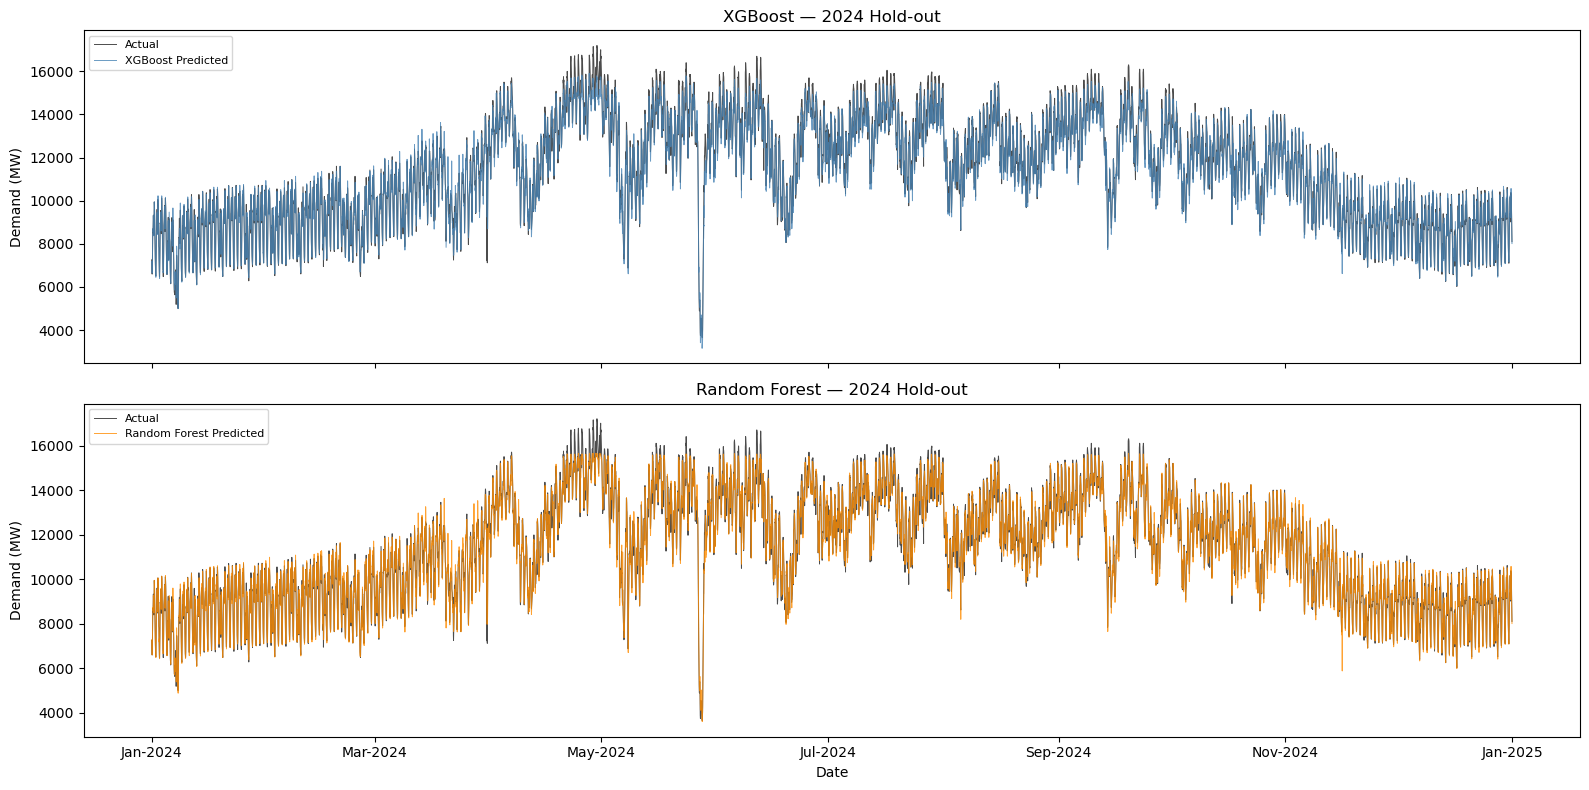

In [28]:
# Prediction vs Actual
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
for ax, preds, label, color in zip(
        axes,
        [xgb_preds, rf_preds],
        ['XGBoost', 'Random Forest'],
        ['steelblue', 'darkorange']):
    ax.plot(dt_test.values, y_test.values, color='black',
            lw=0.7, alpha=0.7, label='Actual')
    ax.plot(dt_test.values, preds, color=color,
            lw=0.7, alpha=0.8, label=f'{label} Predicted')
    ax.set(ylabel='Demand (MW)', title=f'{label} — 2024 Hold-out')
    ax.legend(loc='upper left', fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%Y'))
plt.xlabel('Date'); plt.tight_layout(); plt.show()

---
## SECTION 9 — FEATURE IMPORTANCE

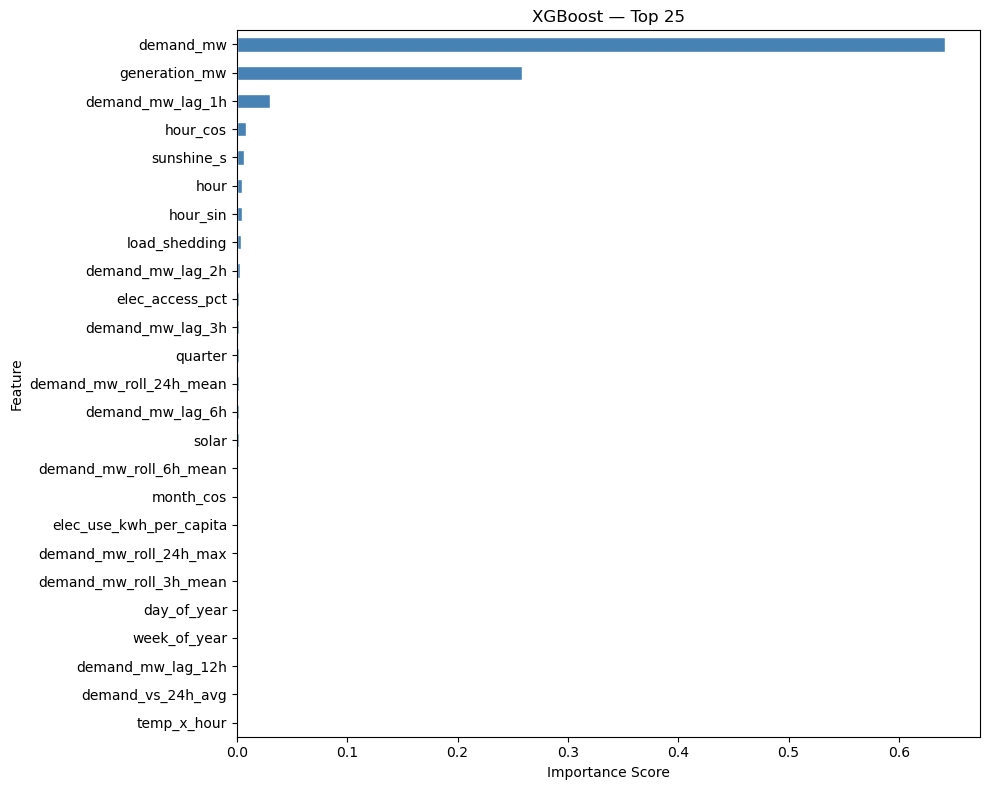

Top 10 features:
demand_mw           0.641374
generation_mw       0.258140
demand_mw_lag_1h    0.029772
hour_cos            0.008142
sunshine_s          0.006452
hour                0.005041
hour_sin            0.004515
load_shedding       0.003615
demand_mw_lag_2h    0.002500
elec_access_pct     0.002329


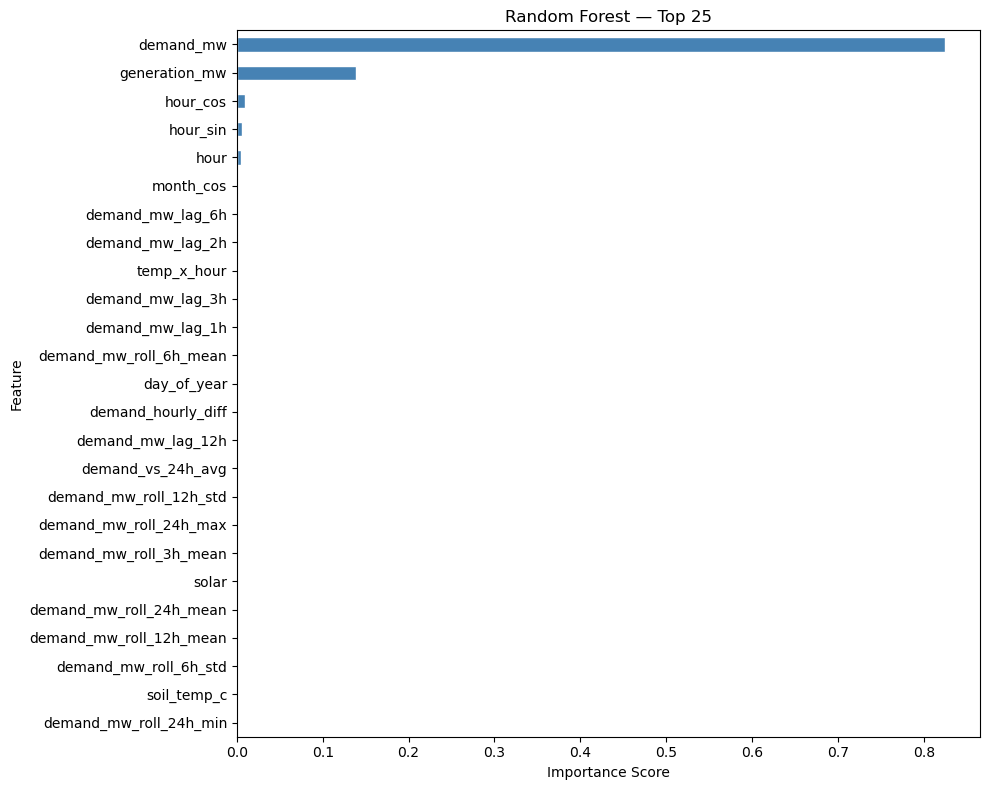

Top 10 features:
demand_mw           0.824253
generation_mw       0.138470
hour_cos            0.009840
hour_sin            0.005685
hour                0.004615
month_cos           0.001752
demand_mw_lag_6h    0.001284
demand_mw_lag_2h    0.001153
temp_x_hour         0.001136
demand_mw_lag_3h    0.001081


In [26]:
def plot_feature_importance(model, feature_names, top_n=25, title='Feature Importances'):
    fi = pd.Series(model.feature_importances_,
                   index=feature_names).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(10, 8))
    fi.head(top_n).sort_values().plot(
        kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set(title=f'{title} — Top {top_n}',
           xlabel='Importance Score', ylabel='Feature')
    plt.tight_layout(); plt.show()
    print(f'Top 10 features:\n{fi.head(10).to_string()}')
    return fi


xgb_fi = plot_feature_importance(xgb_model, FEATURE_COLS, title='XGBoost')
rf_fi  = plot_feature_importance(rf_model,  FEATURE_COLS, title='Random Forest')

---
## SECTION 10 — RESIDUAL ANALYSIS

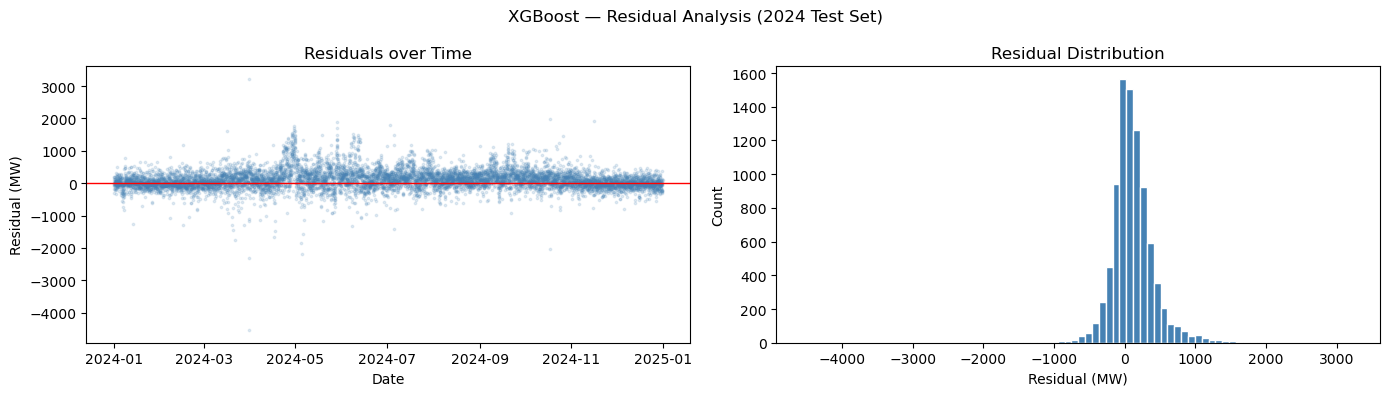

Mean residual: 108.02 MW  |  Std: 309.73 MW
Within ±500MW: 90.6%


In [29]:
residuals = y_test.values - xgb_preds
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(dt_test.values, residuals, alpha=0.15, s=3, color='steelblue')
axes[0].axhline(0, color='red', lw=1)
axes[0].set(title='Residuals over Time', xlabel='Date', ylabel='Residual (MW)')
axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='white')
axes[1].set(title='Residual Distribution', xlabel='Residual (MW)', ylabel='Count')
plt.suptitle('XGBoost — Residual Analysis (2024 Test Set)', fontsize=12)
plt.tight_layout(); plt.show()
print(f'Mean residual: {residuals.mean():.2f} MW  |  Std: {residuals.std():.2f} MW')
print(f'Within ±500MW: {100*(np.abs(residuals)<500).mean():.1f}%')

---
## SECTION 11 — SUMMARY REPORT

### Data Cleaning Rationale
- Non-hourly PGCB readings (17:30, 18:30) rounded to nearest hour; max demand kept per hour.
- Demand spikes smoothed with rolling IQR fence (7-day window, 3× multiplier) to avoid
  removing valid night-time minima that a global IQR would misclassify.
- Annual economic data lagged 1 year (World Bank publishes with ~1-year delay).

### Feature Engineering Choices
- **Lags (1h, 24h, 168h)** are the three strongest signals — immediate autocorrelation, daily, weekly seasonality.
- **Cyclical encoding** (sin/cos) prevents the model treating hour=23 and hour=0 as distant.
- **Rolling std** captures demand volatility during weather transitions.
- **Heat index** directly models AC cooling load better than raw temperature alone.
- **Economic indicators** (GDP, population, electricity access) shift the baseline level year-over-year.